# Module 1. Ex(o)ploring other worlds

In <a href="./MODULE0.ipynb"> <code>MODULE0.ipynb</code></a>, you proved that the variance in a star's lightcurve was due to both its <b>proper motion</b> and an exoplanet transiting it. Now let's see if you can use this knowledge to discover some more exoplanets. 

## Learning goals: 
- Explore how messy time-series signals can be deconstructed into their periodic components 
- Use real data from the Transiting Exoplanet Survey Satellite (TESS) to connect the observables of an exoplanet's lightcurve to physical quantites of the system. 

First, as always, we'll install our dependencies: 

In [1]:
import setup as s
from setup import * 

Installing dependencies...
Processing /home/conda/feedstock_root/build_artifacts/appnope_1733332318622/work (from -r requirements.txt (line 1))
Done!


ERROR: Could not install packages due to an OSError: [Errno 2] No such file or directory: '/System/Volumes/Data/home/conda/feedstock_root/build_artifacts/appnope_1733332318622/work'



Could not import regions, which is required for some of the functionalities of this module.
APOGEE allStar found!


Now, as you saw in Module 0, the lightcurve of a star with a transiting exoplanet can be broken down into two components: 
1. The star's proper motion
2. The exoplanet's periodic transit

Now, let's explore how noise can mask these periodic signals. 

Let's test this using one of the exoplanets listed in the <a href="./transiting_exoplanets.csv"><code>transiting_exoplanets.csv</code></a> file. 

In [ ]:
planet="Kepler-5 b" # enter the name of your chosen planet here 

In [3]:
# read in the transiting_exoplanets file 
exoplanet_ls = ascii.read("transiting_exoplanets.csv")

In [4]:
index = np.where(exoplanet_ls["pl_name"] == planet)[0][0] # retrieve the index of the table where your target planet is located 
target = exoplanet_ls[index] # retrieve data on your target exoplanet

# print out some fun facts about your planet and its host star
print(f"{target['pl_name']}...")
print(f"\t Resides at RA = {target['ra']:.2f} degrees and DEC = {target['dec']:.2f} degrees")
print(f"\t Orbital period of {target['pl_orbper']:.2f} days")
print(f"\t Radius of {target['pl_rade']:.2f} Earth radii")
print(f"\t Transits its host star for {target['pl_trandur']:.2f} hours")
print(f"{target['pl_name'][:-1]}...")
print(f"\t Radius of {target['st_rad']:.2f} solar radii")
print(f"\t Temperature of {target['st_teff']:.2f} K")

Kepler-5 b...
	 Resides at RA = 299.41 degrees and DEC = 44.04 degrees
	 Orbital period of 3.55 days
	 Radius of 15.22 Earth radii
	 Transits its host star for 4.51 hours
Kepler-5 ...
	 Radius of 1.78 solar radii
	 Temperature of 6295.00 K


Let's use these fun facts to construct an artificial lightcurve using the equations we explored in Module 0. 

To construct a sine function, we need to know: 
1. The amplitude ($A$)
2. The period ($T$) or angular frequency ($\omega$)
3. The phase ($\phi$)

To keep it simple, we'll assume $\phi=0$ for both the proper motion function and the transit function. 

We know the amplitude must correspond to the maximum luminosity of the star and the period will be related to either our orbital motion or the orbital motion of the exoplanet, depending on if we're writing the sine function for proper motion or the transit. 

We'll start by calculating the star's luminosity: 

First, we'll assume our star is <a href="https://en.wikipedia.org/wiki/Black_body">black body</a>. This means that our star's luminosity can be approximated as $L=\sigma_{SB}T^4$ where $\sigma_{SB} \approx 5.67 \times 10^{-5}~\text{erg cm}^{-2}~\text{s}^{-1}~\text{K}^{-4}$. 

Complete the following function: 

In [ ]:
def luminosity(T): 
    sigma_sb = 5.67E-5 # Stefan-Boltzmann constant in cgs units
    ## YOUR CODE HERE
    return L 

Now, since we're presumably some distance away from our target planet, we need to move from luminosity to flux to account for this distance. Recall that flux carries units of $\text{erg cm}^{-2}~\text{s}^{-1}$ while luminosity carries units of $\text{erg s}^{-1}$. Therefore, flux is simply luminosity divided over some surface area (in this case, our distance to the source). 

Assuming the star emits isotropically: 
$$F = \frac{L}{4\pi d^2}$$

Complete the following function: 

In [ ]:
def flux(L, d): 
    ## YOUR CODE HERE
    return F

Although we can easily obtain the period of our exoplanet's transits, accounting for the variations in our star's flux as a result of proper motion is more complicated. 

Since proper motion ($\mu$) is given in arcseconds per year, it's really a description of the angular variation of a star over time. Thus, it's really not so different from angular frequency $\omega$!

Of course, for the units to work, we'll want to convert from arcseconds to radians and probably move from years to days (so that we're consistent in units with the period of planet's transits). 

Complete the following function: 

In [ ]:
def pm_to_angfreq(mu): 
    # hint: 1 arcsecond = 4.8E-6 radians 
    ## YOUR CODE HERE
    return omega

You'll notice that <code>transiting_exoplanets.csv</code> lacks informationn on both the distance and proper motion of the stars. To obtain this information, we'll need to get some data from Gaia. Gaia contains less detailed information that the APOGEE allStar catalog we've discussed, but contains significantly more objects and is therefore more likely to contain our target. 

Additionally, Astropy has some nice functions that allow us to directly query Gaia without downloading anything. 

In [8]:
from astroquery.gaia import Gaia

In preparation for Gaia DR4, the Gaia archive is in evolution. Unfortunately, it may be unstable at times and particular types of queries may time out. Please consider registering for a user account (https://www.cosmos.esa.int/web/gaia-users/register). For questions or advice, please contact the Gaia helpdesk (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk).


In [9]:
Gaia.MAIN_GAIA_TABLE = "gaiadr3.gaia_source" # tell astroquery to use the Gaia DR3 catalog for all queries
pl_coords= SkyCoord.from_name(target['pl_name'][:-1]) # create a SkyCoord object for your target planet's coordinates
j = Gaia.cone_search_async(pl_coords, radius=u.Quantity(1.0, u.arcsec)) # perform a cone search around your target planet's coordinates with a radius of 1 degree 
r = j.get_results() # retrieve the results of the cone search
m = (r["parallax"] > 0)# create a mask to filter out any entries with non-positive parallax (which would indicate that the distance cannot be determined)
r = r[m] # apply the mask to filter the results
r.sort("parallax") # sort the results by parallax (which is a proxy for distance) 
host_star = r[0] # the host star should be the closest star to the target planet, so we take the first entry in the sorted results
print(f"Host star found at ({host_star['ra']:.2f} {host_star['dec']:.2f}), {(1/(host_star['parallax']*1E-3)):.2f} parsecs away")

INFO: Query finished. [astroquery.utils.tap.core]
Host star found at (299.41 44.04), 897.73 parsecs away


We can retrieve our proper motion and distance (note that we'll need to convert from parallax to distance). 

In [10]:
pm = host_star['pm']
d = 1/(host_star['parallax']*1E-3) # convert parallax from milliarcseconds to arcseconds and then to distance in parsecs

Let's use our earlier functions to calculate our luminosity and angular frequency of our star's proper motion and our planet's orbital motion. 

In [11]:
lum= luminosity(target['st_teff'])
f_star = flux(lum, d)
print(f"Flux at Earth from {target['pl_name'][:-1]} is {f_star:.2e} erg/s/cm^2")

Flux at Earth from Kepler-5  is 8.79e+03 erg/s/cm^2


Recall that from Module 0., we learned that transit depth, $D = \frac{\Delta F}{F_{star}}$.

The amplitude of our exoplanet's sine function will be $F_{star} - \Delta F$. 

We can retrieve $D$ and compute $\Delta F$: 

In [37]:
depth = target['pl_trandep']
A_pl = f_star - depth * f_star
print(f"Flux at Earth during {target['pl_name'][:-1]}'s transit is {A_pl:.2e} erg/s/cm^2")

Flux at Earth during Kepler-5 's transit is 2.62e+03 erg/s/cm^2


Now, we'll obtain the orbital frequency of our exoplanet and the oscillation frequency of our host star's motion on the sky: 

In [38]:
pl_omega = 2*np.pi/target['pl_orbper'] # calculate the planet's orbital angular frequency in radians/day
host_omega = pm_to_angfreq(pm) # calculate the host star's angular frequency in radians/day based on its proper motion
print(f"{target['pl_name']}'s orbital angular frequency is {pl_omega:.2f} rad/day")
print(f"{target['pl_name'][:-1]}'s host star's angular frequency is {host_omega:.2e} rad/day")

Kepler-5 b's orbital angular frequency is 1.77 rad/day
Kepler-5 's host star's angular frequency is 4.28e-08 rad/day


Now, we'll define the flux variation of our objects according to the following function: 
$$ F(t) = A\sin{(\omega t) + \phi}$$

In [39]:
## choose how long you want to observe and the frequency of the observations you take 
cadence =0.05 # days
observation_length = 30 # days 
time = np.arange(0, observation_length, cadence) # create an array of observation times from 0 to the total observation length with steps equal to the cadence

In [40]:
F_var_star = f_star * np.sin(host_omega * time) # calculate the star's flux variation over time due to its proper motion
F_var_pl = A_pl * np.sin(pl_omega * time) # calculate the planet's flux variation over time due to its orbit around the host star
F_total = F_var_star + F_var_pl # calculate the total flux variation over time as the sum of the star's and planet's contributions

Text(0, 0.5, 'Normalized Flux')

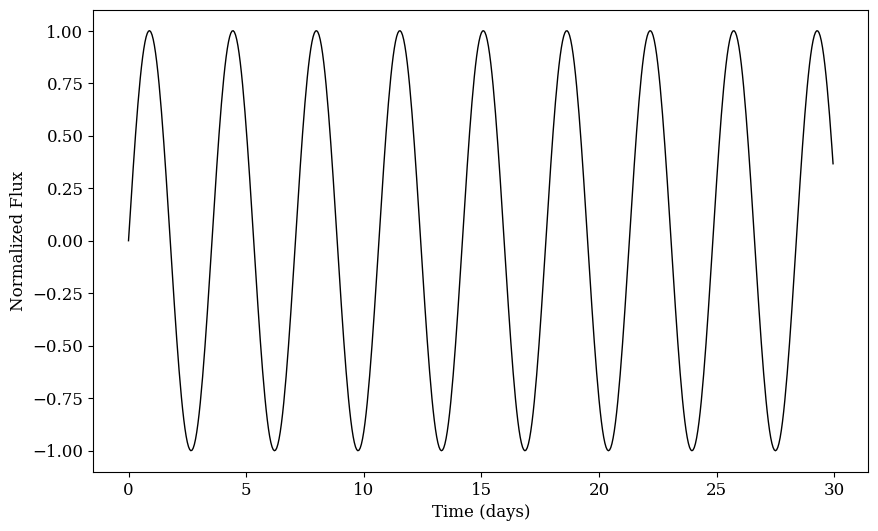

In [42]:
fig, ax = plt.subplots(figsize=(10,6))
ax.plot(time, F_total/np.max(F_total), color="k")
ax.set_xlabel("Time (days)")
ax.set_ylabel("Normalized Flux")


Now, let's add some random noise! 

In [43]:
# use from random sine functions to generate noise 
num = 20 # number of noise components to add
amp = np.random.uniform(0.1, np.max(F_total), size=num) # random amplitudes for the noise components
freq = np.random.uniform(0.1, 10, size=num) # random frequencies for the noise components in cycles per day
phase = np.random.uniform(0, 2*np.pi, size=num) # random phases for the noise components
noise = np.zeros_like(time) # initialize an array to hold the noise values
for a, f, p in zip(amp, freq, phase):
    noise += a * np.sin(2 * np.pi * f * time + p) # add each noise component to the total noise


We'll replot our signal: 

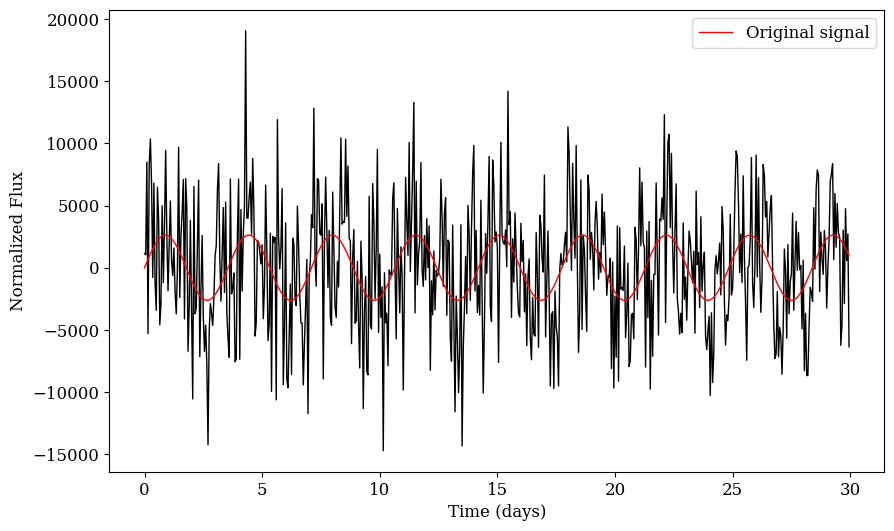

In [44]:
fig, ax = plt.subplots(figsize=(10,6))
ax.plot(time,noise+F_total, color = 'k')
ax.plot(time, F_total, color = 'r', label = "Original signal")
ax.set_xlabel("Time (days)")
ax.set_ylabel("Normalized Flux")
ax.legend()


Play around with different levels of noise. You should begin to see the challenge. 

Fortunately, there's this really cool tool called a Fourier transform that allows us to unmask hidden periodic signals by examining our signal in frequency space rather than time space. Fourier transforms present as a pretty intimidating concept because they are mathematically defined as the following: 
$$ f(\xi) = \int_{-\infty}^{+\infty} f(x) e^{-i2\pi \xi x} dx $$

However, all this integral is really doing is moving from time --> frequency. 

Check it out! 

Text(0, 0.5, 'Amplitude')

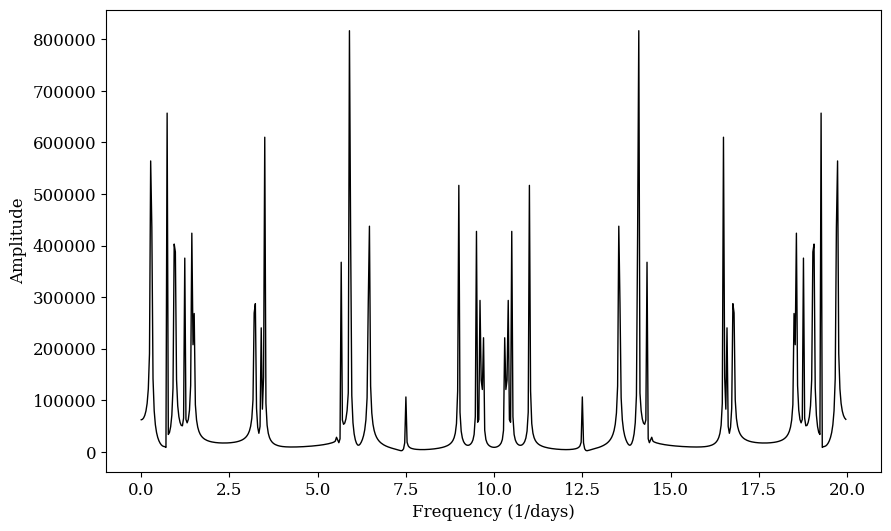

In [45]:
noisy_signal = F_total + noise
fft = np.fft.fft(noisy_signal)
N = len(time) 
n = np.arange(N)
T = N*cadence 
frequencies = n/T 
fig, ax = plt.subplots(figsize=(10,6))
ax.plot(frequencies, np.abs(fft), color = 'k')
ax.set_xlabel("Frequency (1/days)")
ax.set_ylabel("Amplitude")

If you print out the random frequencies we used to generate the noise, you should be able to identify them in the plot!

But, obviously, in real life, we wouldn't know the frequencies that are combined to product our noise. But, we should notice that, because our noise is random, it's different every time. Therefore, by looking for the lines in our signal that do not change across different observations, we can identify the signal that is caused by the transit of our exoplanet. Let's generate noise several different times and plot our results! 

Text(0, 0.5, 'Amplitude')

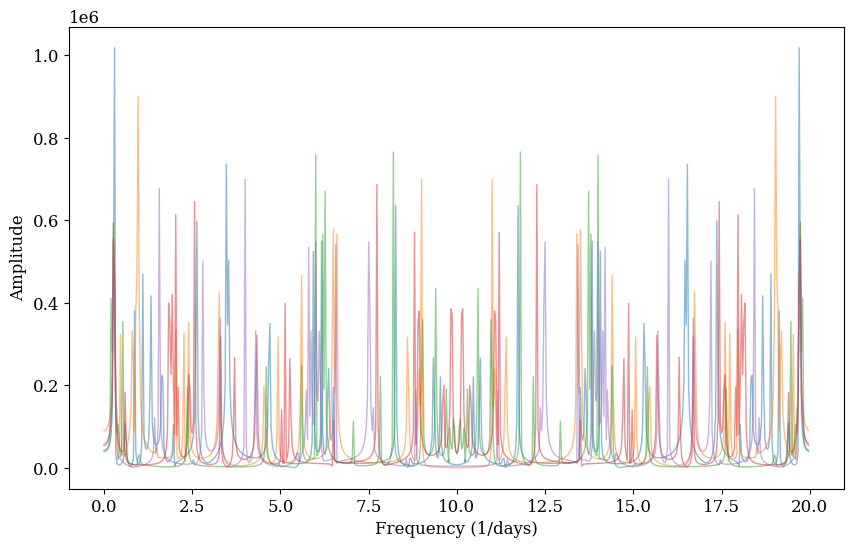

In [46]:
fig, ax = plt.subplots(figsize=(10,6))
# use from random sine functions to generate noise 
num = 20 # number of noise components to add
amp = np.random.uniform(0.1, np.max(F_total), size=num) # random amplitudes for the noise components
freq = np.random.uniform(0.1, 10, size=num) # random frequencies for the noise components in cycles per day
phase = np.random.uniform(0, 2*np.pi, size=num) # random phases for the noise components
noise = np.zeros_like(time) # initialize an array to hold the noise values
for a, f, p in zip(amp, freq, phase):
    noise += a * np.sin(2 * np.pi * f * time + p) # add each noise component to the total noise
noisy_signal = F_total + noise
fft = np.fft.fft(noisy_signal)
N = len(time) 
n = np.arange(N)
T = N*cadence 
frequencies = n/T 
ax.plot(frequencies, np.abs(fft), alpha = 0.5)

num = 20 # number of noise components to add
amp = np.random.uniform(0.1, np.max(F_total), size=num) # random amplitudes for the noise components
freq = np.random.uniform(0.1, 10, size=num) # random frequencies for the noise components in cycles per day
phase = np.random.uniform(0, 2*np.pi, size=num) # random phases for the noise components
noise = np.zeros_like(time) # initialize an array to hold the noise values
for a, f, p in zip(amp, freq, phase):
    noise += a * np.sin(2 * np.pi * f * time + p) # add each noise component to the total noise
noisy_signal = F_total + noise
fft = np.fft.fft(noisy_signal)
N = len(time) 
n = np.arange(N)
T = N*cadence 
frequencies = n/T 
ax.plot(frequencies, np.abs(fft), alpha = 0.5)

num = 20 # number of noise components to add
amp = np.random.uniform(0.1, np.max(F_total), size=num) # random amplitudes for the noise components
freq = np.random.uniform(0.1, 10, size=num) # random frequencies for the noise components in cycles per day
phase = np.random.uniform(0, 2*np.pi, size=num) # random phases for the noise components
noise = np.zeros_like(time) # initialize an array to hold the noise values
for a, f, p in zip(amp, freq, phase):
    noise += a * np.sin(2 * np.pi * f * time + p) # add each noise component to the total noise
noisy_signal = F_total + noise
fft = np.fft.fft(noisy_signal)
N = len(time) 
n = np.arange(N)
T = N*cadence 
frequencies = n/T 
ax.plot(frequencies, np.abs(fft), alpha = 0.5)

num = 20 # number of noise components to add
amp = np.random.uniform(0.1, np.max(F_total), size=num) # random amplitudes for the noise components
freq = np.random.uniform(0.1, 10, size=num) # random frequencies for the noise components in cycles per day
phase = np.random.uniform(0, 2*np.pi, size=num) # random phases for the noise components
noise = np.zeros_like(time) # initialize an array to hold the noise values
for a, f, p in zip(amp, freq, phase):
    noise += a * np.sin(2 * np.pi * f * time + p) # add each noise component to the total noise
noisy_signal = F_total + noise
fft = np.fft.fft(noisy_signal)
N = len(time) 
n = np.arange(N)
T = N*cadence 
frequencies = n/T 
ax.plot(frequencies, np.abs(fft), alpha = 0.5)

num = 20 # number of noise components to add
amp = np.random.uniform(0.1, np.max(F_total), size=num) # random amplitudes for the noise components
freq = np.random.uniform(0.1, 10, size=num) # random frequencies for the noise components in cycles per day
phase = np.random.uniform(0, 2*np.pi, size=num) # random phases for the noise components
noise = np.zeros_like(time) # initialize an array to hold the noise values
for a, f, p in zip(amp, freq, phase):
    noise += a * np.sin(2 * np.pi * f * time + p) # add each noise component to the total noise
noisy_signal = F_total + noise
fft = np.fft.fft(noisy_signal)
N = len(time) 
n = np.arange(N)
T = N*cadence 
frequencies = n/T 
ax.plot(frequencies, np.abs(fft), alpha = 0.5)

ax.set_xlabel("Frequency (1/days)")
ax.set_ylabel("Amplitude")



Do you see a place where all the lines coincide? 

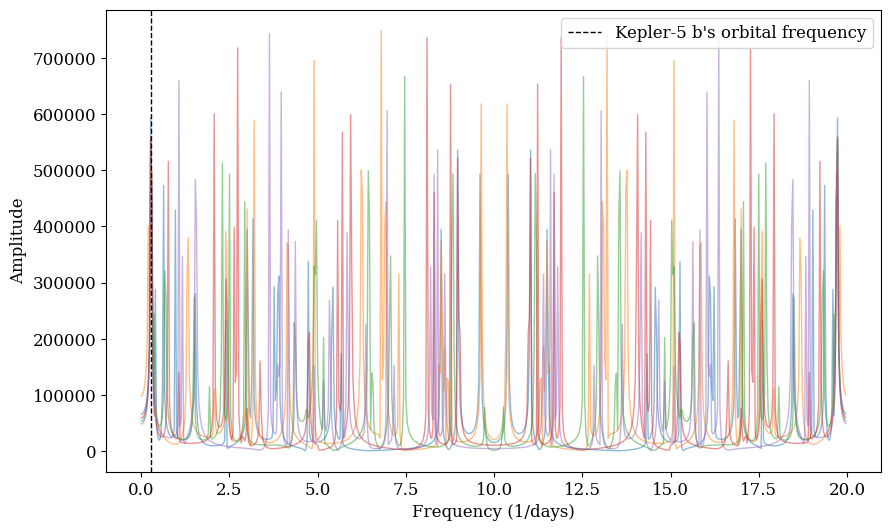

In [50]:
fig, ax = plt.subplots(figsize=(10,6))
# use from random sine functions to generate noise 
num = 20 # number of noise components to add
amp = np.random.uniform(0.1, np.max(F_total), size=num) # random amplitudes for the noise components
freq = np.random.uniform(0.1, 10, size=num) # random frequencies for the noise components in cycles per day
phase = np.random.uniform(0, 2*np.pi, size=num) # random phases for the noise components
noise = np.zeros_like(time) # initialize an array to hold the noise values
for a, f, p in zip(amp, freq, phase):
    noise += a * np.sin(2 * np.pi * f * time + p) # add each noise component to the total noise
noisy_signal = F_total + noise
fft = np.fft.fft(noisy_signal)
N = len(time) 
n = np.arange(N)
T = N*cadence 
frequencies = n/T 
ax.plot(frequencies, np.abs(fft), alpha = 0.5)

num = 20 # number of noise components to add
amp = np.random.uniform(0.1, np.max(F_total), size=num) # random amplitudes for the noise components
freq = np.random.uniform(0.1, 10, size=num) # random frequencies for the noise components in cycles per day
phase = np.random.uniform(0, 2*np.pi, size=num) # random phases for the noise components
noise = np.zeros_like(time) # initialize an array to hold the noise values
for a, f, p in zip(amp, freq, phase):
    noise += a * np.sin(2 * np.pi * f * time + p) # add each noise component to the total noise
noisy_signal = F_total + noise
fft = np.fft.fft(noisy_signal)
N = len(time) 
n = np.arange(N)
T = N*cadence 
frequencies = n/T 
ax.plot(frequencies, np.abs(fft), alpha = 0.5)

num = 20 # number of noise components to add
amp = np.random.uniform(0.1, np.max(F_total), size=num) # random amplitudes for the noise components
freq = np.random.uniform(0.1, 10, size=num) # random frequencies for the noise components in cycles per day
phase = np.random.uniform(0, 2*np.pi, size=num) # random phases for the noise components
noise = np.zeros_like(time) # initialize an array to hold the noise values
for a, f, p in zip(amp, freq, phase):
    noise += a * np.sin(2 * np.pi * f * time + p) # add each noise component to the total noise
noisy_signal = F_total + noise
fft = np.fft.fft(noisy_signal)
N = len(time) 
n = np.arange(N)
T = N*cadence 
frequencies = n/T 
ax.plot(frequencies, np.abs(fft), alpha = 0.5)

num = 20 # number of noise components to add
amp = np.random.uniform(0.1, np.max(F_total), size=num) # random amplitudes for the noise components
freq = np.random.uniform(0.1, 10, size=num) # random frequencies for the noise components in cycles per day
phase = np.random.uniform(0, 2*np.pi, size=num) # random phases for the noise components
noise = np.zeros_like(time) # initialize an array to hold the noise values
for a, f, p in zip(amp, freq, phase):
    noise += a * np.sin(2 * np.pi * f * time + p) # add each noise component to the total noise
noisy_signal = F_total + noise
fft = np.fft.fft(noisy_signal)
N = len(time) 
n = np.arange(N)
T = N*cadence 
frequencies = n/T 
ax.plot(frequencies, np.abs(fft), alpha = 0.5)

num = 20 # number of noise components to add
amp = np.random.uniform(0.1, np.max(F_total), size=num) # random amplitudes for the noise components
freq = np.random.uniform(0.1, 10, size=num) # random frequencies for the noise components in cycles per day
phase = np.random.uniform(0, 2*np.pi, size=num) # random phases for the noise components
noise = np.zeros_like(time) # initialize an array to hold the noise values
for a, f, p in zip(amp, freq, phase):
    noise += a * np.sin(2 * np.pi * f * time + p) # add each noise component to the total noise
noisy_signal = F_total + noise
fft = np.fft.fft(noisy_signal)
N = len(time) 
n = np.arange(N)
T = N*cadence 
frequencies = n/T 
ax.plot(frequencies, np.abs(fft), alpha = 0.5)

ax.axvline(1/target['pl_orbper'], color='k', linestyle='--', label=f"{target['pl_name']}'s orbital frequency")
ax.set_xlabel("Frequency (1/days)")
ax.set_ylabel("Amplitude")

ax.legend()


Now, let's try this on some real data! 

Launched in 2018 as a successor to the Kepler spacecraft, TESS resides in a high Earth equatorial orbit and surveys neighboring suns by staring at $2300~\text{deg}^2$ of the sky for 27 days at a time. If a planet transit during those 27 days, TESS will observe a dip in its host star's brightness.

<figure>
  <img src="helpful_figures/tess.webp" style="display: block; margin-left: auto; margin-right: auto; width: 50%;">
  <div align="center">
  <p>An artistic rendition of TESS courtesy of <a href="https://science.nasa.gov/mission/tess/"> NASA </a> 
  </p>
  </div>
</figure>

The following steps will guide you through the process of detecting a transit using TESS data. 

### Step 1. Download some data 
I've built a function called tess_data_download that takes in the parameters <code>num_obj</code>, <code>order_random</code>, <code>target_index</code>, and <code>search_radius</code>. If no parameters are inputted, light curves for the exoplanets in <a href = "https://exoplanetarchive.ipac.caltech.edu/cgi-bin/TblView/nph-tblView?app=ExoTbls&config=TD" > NASA's table of transiting exoplanets </a>. 

The parameters are as follows: 
<p style="text-indent: 50px;">
<code>num_obj</code>: Tells the function to only download a certain number of objects. 
<p style="text-indent: 50px;">
<code>order_random</code>: If set to False (default) the objects will be ordered in sequential order from the table. Otherwise, objects will be randomly selected from the table
<p style="text-indent: 50px;">
<code>target_index</code>: Selects the index of a specific object you want from the table
<p style="text-indent: 50px;">
<code>search_radius</code>: Defaults to 0.1 arcseconds and determines the radius a TESS detection must fall from the planet's radius to be considered a valid match
</p>

In [51]:
file_path = './tess_data/'

In [52]:
s.tess_data_download(target_name=planet) 

Target name resolved.
File has already been downloaded


mkdir: tess_data: File exists


### Step 2. Create a lightcurve

Once the download has finished, we can retrieve all the <b>lightcurve</b> we now have for this object. 

In [53]:
target_obj = planet.replace(" ", "_")
target_file_path = file_path+target_obj
lightcurve_files = s.glob.glob(s.os.path.join(target_file_path, '*'))

We can plot just one of our lightcurves to make sure it looks okay. 

Text(0, 0.5, 'Flux (erg/cm$^2$/s)')

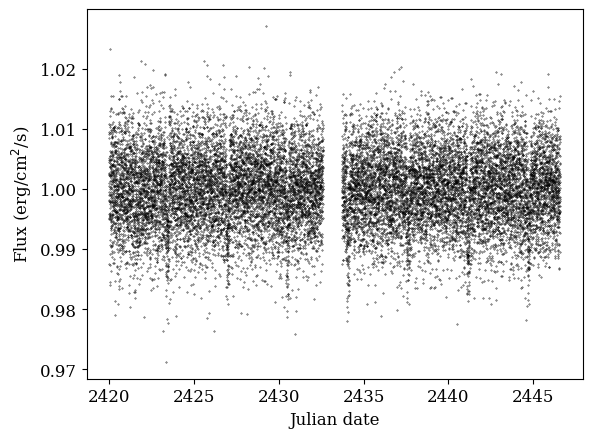

In [54]:
hdu_list = fits.open(lightcurve_files[0], memmap=True)
data = Table(hdu_list[1].data)
# remove data that is flagged as being high quality and data that does not have a value
mask = (data['QUALITY'] == 0) & (~np.isnan(data['PDCSAP_FLUX'])) 
data_filtered = data[mask]
plt.scatter(data['TIME'], data['PDCSAP_FLUX']/np.nanmedian(data['PDCSAP_FLUX']),color = 'k', s= 0.1)
plt.xlabel('Julian date')
plt.ylabel(r'Flux (erg/cm$^2$/s)')

You should see some small dips in your lightcurve--these are the transits of your planet! But, we also see a lot of noise. Luckily, <code>Astropy</code> offers a much more sophisticated method for identifying underlying periodic signals than the one we just worked through. However, it works the same way. It's called the Box-Least-Squared (BLS) method because it is intended to identify the boxy shape of transits. 

You can read more about BLS and its <code>astropy</code> implementation<a href="https://docs.astropy.org/en/stable/timeseries/bls.html" > here</a>.

To do this, we'll want multiple transits which we can't detect in a single observation unless the orbital period of the planet is less than 13.5 Earth days (TESS typically observes a given star for 27 days). 

Good thing we have multiple observations! Let's merge all of our times, fluxes, and flux errors for each observation into a single list. 

In [55]:
time = []
flux = []
fluxerr = []
for file in lightcurve_files: 
    hdu_list = fits.open(file, memmap=True)
    data = Table(hdu_list[1].data)
    
    #repeat our filtering process 
    mask = (data['QUALITY'] == 0) & (~np.isnan(data['PDCSAP_FLUX']))
    data_filtered = data[mask]
    time = list(data['TIME'])
    flux = list(data['PDCSAP_FLUX'])
    flux_normalized = flux/np.nanmedian(flux)
    fluxerr = list(data['PDCSAP_FLUX_ERR'])
    fluxerr_normalized = fluxerr/np.nanmedian(fluxerr)
    time.extend(time)
    flux.extend(flux_normalized)
    fluxerr.extend(fluxerr_normalized)
# remove any nan values just to be safe
m = np.isnan(flux) | np.isnan(fluxerr)
flux = np.array(flux)[~m]
fluxerr=np.array(fluxerr)[~m]
time = np.array(time)[~m]

Now that we've merged our data, let's apply <code> astropy</code>'s <code>BoxLeastSquares</code> function. As we do this, we'll construct something called a "periodogram," which is really just what we plotted above. 

### Step 3. Construct a periodogram

In [56]:
# may take a minute to run depending on how messy the data you selected is. 
model = BoxLeastSquares(np.array(time) * u.day, np.array(flux), dy= np.array(fluxerr))
durations = np.linspace(0.1, 0.2, 20) * u.day # you'll want to change this to narrow in on the period of your target planet
results = model.autopower(durations, frequency_factor=5.0)

We can plot our periodogram by doing the following. I've added a bit to the code that will highlight the transit period that algorithm selects and the harmonics.

T = 3.55 days 


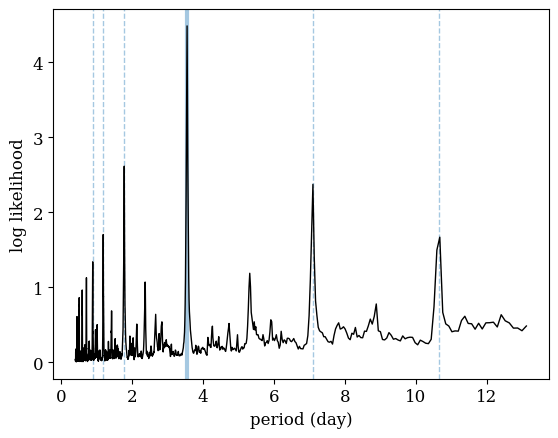

In [57]:
transitperiod = results.period[np.argmax(results.power)]
plt.axvline(transitperiod.value, alpha=0.4, lw=3)
for n in range(2, 5):
    pos_harmonic = n*transitperiod.value
    neg_harmonic= transitperiod.value / n
    if(pos_harmonic <= np.max((results.period).value)): 
        plt.axvline(n*transitperiod.value, alpha=0.4, lw=1, linestyle="dashed")
    if(neg_harmonic >= np.min((results.period).value)):
        plt.axvline(transitperiod.value / n, alpha=0.4, lw=1, linestyle="dashed")
plt.plot(results.period, results.power, color = 'k')
plt.xlabel("period (day)")
plt.ylabel("log likelihood")
print(f"T = {transitperiod.value:.2f} days ")

<b>Search up the orbital period of the exoplanet you selected. Is the output of the code consistent with what you find? How does changing the input parameters of the model affect your result? </b>

<b> Answer:</b> 

Alongside obtaining our period, we can also obtain the depth of our transit, when in the orbital period the transit occurs, how long the transit takes, etc. 

In [60]:
transitperiod = results.period[np.argmax(results.power)].value
transitdepth = results.depth[np.argmax(results.power)]
transittime = results.transit_time[np.argmax(results.power)].value
transitduration = results.duration[np.argmax(results.power)].value

print(f"Period: {transitperiod:.2f}")
print(f"Transit depth: {transitdepth:.2f}")
print(f"Transit time: {transittime:.2f}")
print(f"Transit duration: {transitduration:.2f}")

Period: 3.55
Transit depth: 0.09
Transit time: 2771.18
Transit duration: 0.17


<b> Repeat the steps above on any number of exoplanets (use the download function to get more!). Be sure to save the statistics listed above for each planet. </b>

In [64]:
pl_name = []
pl_ra = []
pl_dec = []
period_ls = []
depth_ls = []
trtime_ls = []
duration_ls=[]

## YOUR IMPLEMENTATION HERE

pl_name.append(planet)
hdu_list = fits.open(lightcurve_files[0], memmap=True)
pl_ra.append(hdu_list[0].header['RA_OBJ'])
pl_dec.append(hdu_list[0].header['DEC_OBJ'])
period_ls.append(transitperiod)
depth_ls.append(transitdepth)
trtime_ls.append(transittime)
duration_ls.append(transitduration)

In [62]:
# run the following code once you've retrieved statistics for all planets of interest 

exoplanet_tbl = Table([pl_name, pl_ra, pl_dec, period_ls, depth_ls, trtime_ls, duration_ls], names = ("name", "ra", "dec", "period", "depth", "time", "duration"))

In [65]:
# export your table 

ascii.write(exoplanet_tbl, 'exoplanet_tbl.csv', format = 'csv')

## You're ready to explore Module 2! 